In [ ]:
!pip install -q kagglehub

In [2]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ NLTK assets downloaded")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ NLTK assets downloaded


In [3]:
import os
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print("Dataset path:", path)

csv_path = None

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

print("CSV Found:", csv_path)

df = pd.read_csv(csv_path)

print(df.head())

print("\nShape:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews
CSV Found: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


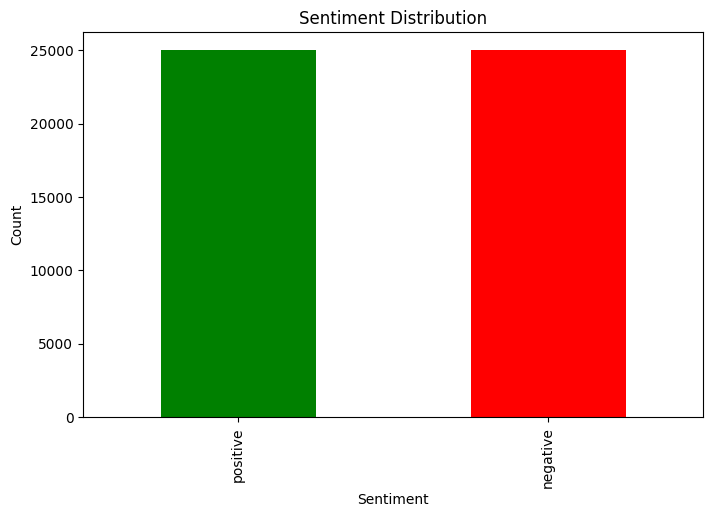

In [5]:
plt.figure(figsize=(8,5))

df['sentiment'].value_counts().plot(
    kind='bar',
    color=['green','red']
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

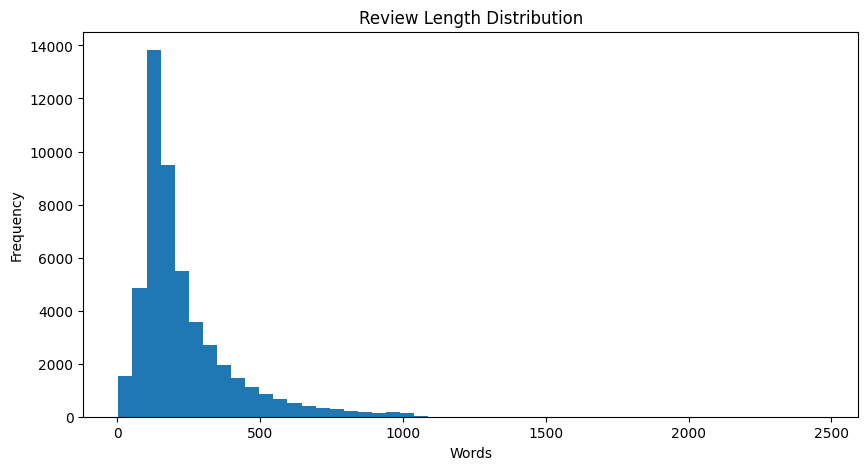

In [6]:
df['review_length'] = df['review'].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(10,5))

plt.hist(
    df['review_length'],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [7]:
lemmatizer = WordNetLemmatizer()

NEGATIONS = {
    'no',
    'not',
    'nor',
    'none',
    'never',
    'neither'
}

base_stopwords = set(stopwords.words('english'))
custom_stopwords = base_stopwords - NEGATIONS


def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN


def preprocess_review(text):

    text = re.sub(r'<[^>]+>', ' ', text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in custom_stopwords
        and len(word) > 1
    ]

    tagged = pos_tag(tokens)

    tokens = [
        lemmatizer.lemmatize(
            token,
            get_wordnet_pos(pos)
        )
        for token, pos in tagged
    ]

    return " ".join(tokens)

print("Preprocessor Ready")

Preprocessor Ready


In [8]:
print("Processing Reviews...")

df['cleaned_review'] = df['review'].apply(
    preprocess_review
)

print("Done")

Processing Reviews...
Done


In [9]:
df['label'] = df['sentiment'].map(
    {
        'positive':1,
        'negative':0
    }
)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_review'],
    df['label'],
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000,
    min_df=2,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)

(40000, 50000)
(10000, 50000)


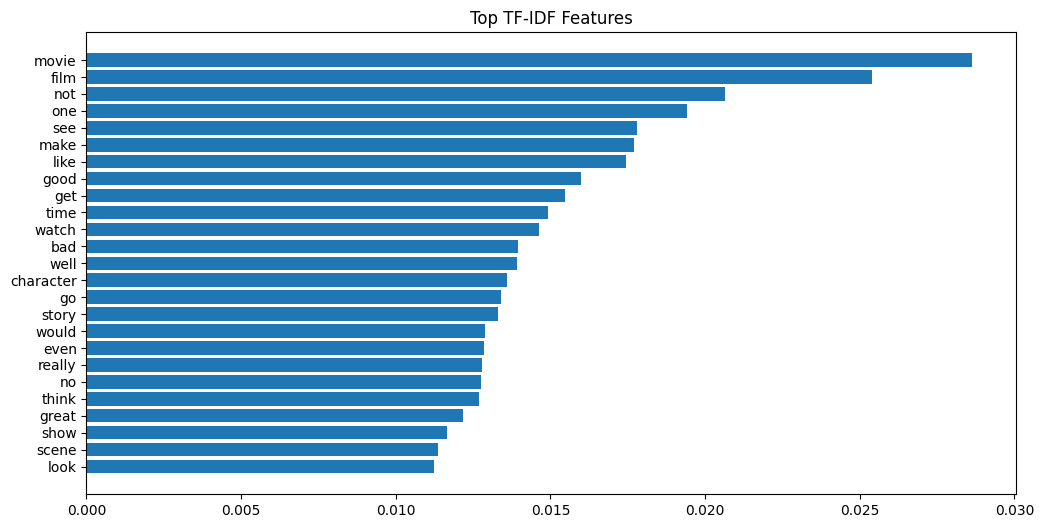

In [10]:
feature_names = tfidf.get_feature_names_out()

scores = np.asarray(
    X_train.mean(axis=0)
).flatten()

top = scores.argsort()[::-1][:25]

top_terms = [feature_names[i] for i in top]
top_scores = [scores[i] for i in top]

plt.figure(figsize=(12,6))

plt.barh(
    top_terms[::-1],
    top_scores[::-1]
)

plt.title("Top TF-IDF Features")

plt.show()

In [11]:
mnb_model = MultinomialNB(alpha=1.0)

mnb_model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [12]:
y_pred = mnb_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      5000
           1       0.88      0.89      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Accuracy: 88.44 %


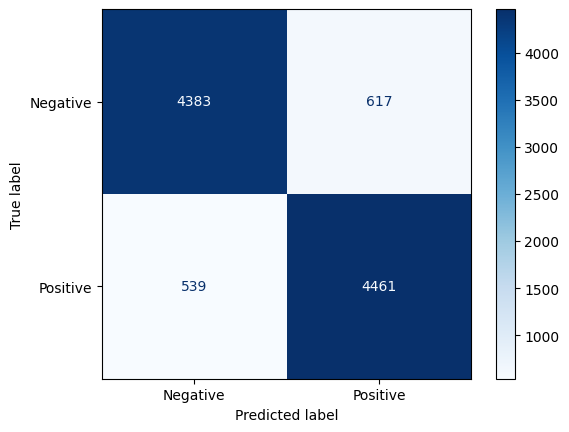

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot(cmap='Blues')

plt.show()

In [14]:
cnb_model = ComplementNB()

cnb_model.fit(
    X_train,
    y_train
)

cnb_pred = cnb_model.predict(
    X_test
)

cnb_acc = accuracy_score(
    y_test,
    cnb_pred
)

print(
    "MultinomialNB:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

print(
    "ComplementNB:",
    round(
        cnb_acc*100,
        2
    ),
    "%"
)

MultinomialNB: 88.44 %
ComplementNB: 88.44 %


In [15]:
def predict_sentiment(text):

    cleaned = preprocess_review(text)

    vectorized = tfidf.transform(
        [cleaned]
    )

    prediction = mnb_model.predict(
        vectorized
    )[0]

    confidence = mnb_model.predict_proba(
        vectorized
    )[0]

    label = (
        "POSITIVE"
        if prediction == 1
        else "NEGATIVE"
    )

    conf = confidence[prediction] * 100

    return label, conf

In [16]:
reviews = [
    "This movie was amazing and brilliant.",
    "Worst movie ever made.",
    "Not bad but could have been better.",
    "I absolutely loved this film."
]

for review in reviews:

    label, confidence = predict_sentiment(review)

    print("\nReview:", review)

    print(
        "Prediction:",
        label
    )

    print(
        "Confidence:",
        round(confidence,2),
        "%"
    )


Review: This movie was amazing and brilliant.
Prediction: POSITIVE
Confidence: 86.49 %

Review: Worst movie ever made.
Prediction: NEGATIVE
Confidence: 88.71 %

Review: Not bad but could have been better.
Prediction: NEGATIVE
Confidence: 88.31 %

Review: I absolutely loved this film.
Prediction: POSITIVE
Confidence: 87.74 %


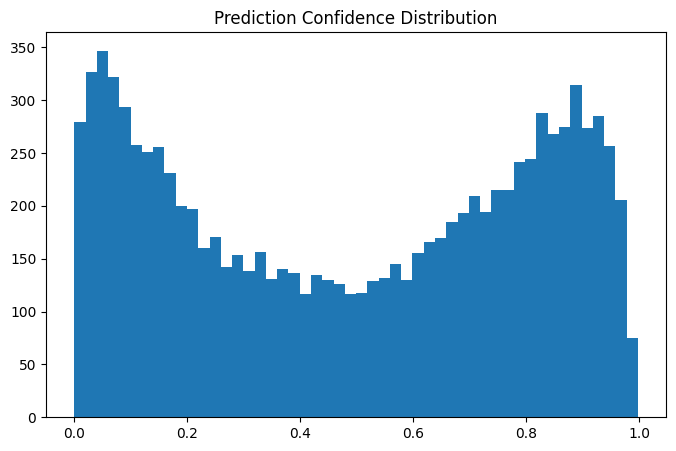

In [17]:
probabilities = mnb_model.predict_proba(
    X_test
)[:,1]

plt.figure(figsize=(8,5))

plt.hist(
    probabilities,
    bins=50
)

plt.title(
    "Prediction Confidence Distribution"
)

plt.show()

In [18]:
print("="*50)

print(
    "FINAL ACCURACY:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

print(
    "VOCABULARY SIZE:",
    len(tfidf.vocabulary_)
)

print(
    "TRAINING RECORDS:",
    len(X_train_text)
)

print("="*50)

FINAL ACCURACY: 88.44 %
VOCABULARY SIZE: 50000
TRAINING RECORDS: 40000
